## Overview

This notebook walks through training the HeteroGNN model using the temporal snapshot graph formulation. Unlike `train_heterognn.ipynb`, which also builds a heterogeneous GNN model, this model uses rGCN convolution layers for implementation. The model used here can be found in `model_rgcn.py`.

 We will import the necessary libraries, load and preprocess the data into the temporal edge graph formulation, instantiate and train the model, and then present our results. Results and figures are analyzed in the Medium blogpost, which can be found here:

https://medium.com/@tushar.aggarwal53/modeling-earthquake-recurrence-with-graph-machine-learning-89001331e146

Note that we do not actually run this model on the real data, since it did not perform well on the synthetic data. However, a few analysis are provided, including a regression task.

## Importing Libraries
In this section, we import all the necessary libraries required for data manipulation, model building, and evaluation.

In [ ]:
from config import LOOKBACK_DAYS, PREDICTION_HORIZONS, DATA_FILE, OUT_DIR, EPOCHS, LR, WEIGHT_DECAY, HIDDEN_DIM, OUT_DIM, BATCH_SIZE, TRAIN_SPLIT, VAL_SPLIT, NUM_LAYERS
from data_utils import load_and_prepare_data, build_temporal_snapshot_graph, process_repeaters_csv
from model_rgcn import RGCN, FocalLoss
import torch
import torch.optim as optim
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from sklearn.metrics import roc_auc_score

import numpy as np
import pandas as pd
import os
os.makedirs(OUT_DIR, exist_ok=True)

In [2]:
torch.manual_seed(1)
torch.cuda.manual_seed(2)
np.random.seed(3)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Model Training, Essential Functions
Note that we start with the essential model training functions in this notebook. The reason this is presented this way is because we actually build the data twice, once for the classification task (classifying if there is an event on each timestep), and once for the regression task (predicting how much time until recurrence on each timestep). Those sections are back to back, and are next.

In [ ]:
def train_model(model, opt, scheduler, loss_fn, train_loader, val_loader, test_loader, use_regression_task, epochs=EPOCHS):
    """
    Trains the model, saving and returning essential information collected during training
    """
    
    # Initialize model
    best_val_auc = 0
    best_val_loss = float("inf")
    best_state = None
    
    history = {
        'epochs': [],
        'train_loss': [],
        'val_epochs': [],
        'val_loss': []
    }
    
    if not use_regression_task:
        history['val_auc'] = []
        for horizon in PREDICTION_HORIZONS:
            history[f'val_auc_{horizon}d'] = []
    
    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        
        for batch in train_loader:
            batch = batch.to(DEVICE)
            logits = model(batch)
            targets = batch.y
            loss = loss_fn(logits, targets)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            
            train_losses.append(loss.item())
        
        scheduler.step()
        history['epochs'].append(epoch)
        history['train_loss'].append(np.mean(train_losses))
        
        # Validation
        if epoch % 5 == 0:
            model.eval()
            val_logits = []
            val_targets = []
            val_losses = []
            
            with torch.no_grad():
                for batch in val_loader:
                    batch = batch.to(DEVICE)
                    logits = model(batch)
                    targets = batch.y
                    val_loss = loss_fn(logits, targets)
                    val_logits.append(logits.cpu())
                    val_targets.append(targets.cpu())
                    val_losses.append(val_loss.item())
            
            val_logits = torch.cat(val_logits, dim = 0).numpy()
            val_targets = torch.cat(val_targets, dim = 0).numpy()
            val_probs = 1 / (1 + np.exp(-val_logits))
            
            if use_regression_task:
                history['val_epochs'].append(epoch)
                mean_val_loss = np.mean(val_losses)
                history['val_loss'].append(mean_val_loss)
                if mean_val_loss < best_val_loss:
                    best_val_loss = mean_val_loss
                    best_state = model.state_dict()

                print(f"Epoch {epoch:03d} | Loss {np.mean(train_losses):.4f} | Val Loss {np.mean(val_losses):.4f}")
            else:
                # Calculate AUC for each horizon
                aucs = []
                for i in range(len(PREDICTION_HORIZONS)):
                    if len(np.unique(val_targets[:, i])) > 1:
                        auc = roc_auc_score(val_targets[:, i], val_probs[:, i])
                        aucs.append(auc)
                        history[f'val_auc_{PREDICTION_HORIZONS[i]}d'].append(auc)
                    else:
                        history[f'val_auc_{PREDICTION_HORIZONS[i]}d'].append(0)
                
                avg_auc = np.mean(aucs) if aucs else 0
                history['val_epochs'].append(epoch)
                history['val_loss'].append(np.mean(val_losses))
                history['val_auc'].append(avg_auc)
                
                if avg_auc > best_val_auc:
                    best_val_auc = avg_auc
                    best_state = model.state_dict()
                
                print(f"Epoch {epoch:03d} | Loss {np.mean(train_losses):.4f} | Val Loss {np.mean(val_losses):.4f} | Val AUC {avg_auc:.4f} | " + " | ".join([f"{PREDICTION_HORIZONS[i]}d: {aucs[i]:.3f}" for i in range(len(aucs))]))
    
    # Load best model
    model.load_state_dict(best_state)

    return model, history

In [ ]:
def compute_metrics(all_preds, all_labels, threshold=0.5):
    """
    Compute different metrics from aggregated predictions and labels.
    """
    # Convert to numpy for sklearn metrics
    preds_proba = F.sigmoid(all_preds).detach().cpu().numpy()
    labels_np = all_labels.detach().cpu().numpy()
    
    # Binary predictions with chosen/optimized threshold
    pred_binary = (torch.sigmoid(all_preds) > threshold).float()
    
    # Basic accuracy
    accuracy = (pred_binary == all_labels).float().mean()
    
    # Confusion matrix components
    true_pos = ((pred_binary == 1) & (all_labels == 1)).sum().item()
    false_pos = ((pred_binary == 1) & (all_labels == 0)).sum().item()
    false_neg = ((pred_binary == 0) & (all_labels == 1)).sum().item()
    true_neg = ((pred_binary == 0) & (all_labels == 0)).sum().item()
    
    # Threshold-based metrics
    precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) > 0 else 0
    recall = true_pos / (true_pos + false_neg) if (true_pos + false_neg) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    
    # Probability-based metrics (require sklearn)
    try:
        roc_auc = roc_auc_score(labels_np, preds_proba)
    except:
        roc_auc = 0.0
    
    
    return {
        # Main metrics
        'accuracy': accuracy.item(),
        'roc_auc': roc_auc,
        'threshold': threshold,  # Include the threshold used
        
        # Classification metrics
        'precision': precision,
        'recall': recall,
        'f1': f1,
        
        # Confusion matrix
        'true_pos': true_pos,
        'false_pos': false_pos,
        'true_neg': true_neg,
        'false_neg': false_neg
    }

Note the options here in `train_rGCN_temporal_snapshot`:
`use_spatial_edges` and `use_spatial_attention` are two ways of running the model. They should not both be true. Spatial edges uses message passing along predefined spatial edges to model spatial information. Spatial attention assumes the nodes are 'fully connected', and learns attention weights for each pair of nodes, using node haversine distance as edge weights to modulate the attention weighting.

`use_loading_rates` instantiates global nodes, that have the loading rate as a feature.

`dist_matrix` is used only if `use_spatial_attention = True`, and is an N x N matrix with pairwise distances between all nodes.

In [ ]:
def train_rGCN_temporal_snapshot(train_loader, val_loader, test_loader, use_regression_task = False, use_spatial_edges = True, use_spatial_attention = False, use_loading_rates = False, dist_matrix = None):
    """Using the provided data, instantiates a model, optimizer, and loss function to execute the training loop"""
    sample = next(iter(train_loader))[0]
    feat_dim = sample.num_node_features["earthquake_source"]
    model = RGCN(feat_dim, NUM_LAYERS, HIDDEN_DIM, OUT_DIM, distance_matrix=dist_matrix, use_regression_task=use_regression_task, use_loading_rate=use_loading_rates, use_spatial_attention=use_spatial_attention, use_spatial_edges=use_spatial_edges)
    opt = optim.AdamW(model.parameters(), lr = LR, weight_decay = WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0 = 20, T_mult = 2)
    if use_regression_task:
        loss_fn = torch.nn.MSELoss()
    else:
        loss_fn = FocalLoss(alpha = 0.70, gamma = 2.0)
    return train_model(model, opt, scheduler, loss_fn, train_loader, val_loader, test_loader, use_regression_task=use_regression_task)

In [80]:
def evaluate_model(model, three_splits, use_regression_task):
    records = []
    metrics_30_day = []
    metrics_90_day = []
    metrics_180_day = []
    for split in three_splits:
        all_out = []
        all_targets = []
        for t, sample in enumerate(split):
            out = model(sample)
            probs = torch.sigmoid(out.detach()).cpu().numpy()
            targets = sample.y.numpy()
            all_out.append(torch.tensor(out))
            all_targets.append(torch.tensor(targets))
            for node_idx, node_pred in enumerate(out):
                if use_regression_task:
                    records.append({
                        'time_index': t,
                        'node_idx': int(node_idx),
                        'true_label': float(sample.y[node_idx, 0]),
                        'predicted_label': float(node_pred),
                    })
                else:
                    for h_idx, horizon in enumerate(PREDICTION_HORIZONS):
                        p = float(probs[node_idx, h_idx])
                        pred = int(p > 0.5)
                        true = int(targets[node_idx, h_idx])

                        records.append({
                            'time_index': t,
                            'node_idx': int(node_idx),
                            'horizon_days': int(horizon),
                            'true_label': true,
                            'predicted_label': pred,
                            'prob_no_slip': 1.0 - p,
                            'prob_slip': p
                        })
        if use_regression_task:
            return pd.DataFrame.from_records(records)
        all_targets = torch.vstack(all_targets)
        all_out = torch.vstack(all_out)
        metrics_30_day_split = compute_metrics(all_out[:, 0], all_targets[:, 0])
        metrics_90_day_split = compute_metrics(all_out[:, 1], all_targets[:, 1])
        metrics_180_day_split = compute_metrics(all_out[:, 2], all_targets[:, 2])
        metrics_30_day.append(metrics_30_day_split)
        metrics_90_day.append(metrics_90_day_split)
        metrics_180_day.append(metrics_180_day_split)
     # Create DataFrame
    return pd.DataFrame.from_records(records), metrics_30_day, metrics_90_day, metrics_180_day

## Train Model on Synthetic Data, Classification Task

This section loads the synthetic data as a classification task, to predict a binary label for each timestep. Note, we set our options to use spatial edges rather than spatial attention, and we left out the global loading rate node.

In [6]:
CLASSIFICATION_USE_SPATIAL_EDGES = True
CLASSIFICATION_USE_SPATIAL_ATTENTION = False
CLASSIFICATION_USE_LOADING_RATES = False

In [32]:
print("Loading data...")
data_file = "../" + DATA_FILE
if "repeaters" in data_file:
    df = process_repeaters_csv(data_file)
else:
    df = load_and_prepare_data(data_file)


print("Building spatial graphs")
all_samples, dist_matrix = build_temporal_snapshot_graph(df, use_regression_task=False, use_spatial_edges=CLASSIFICATION_USE_SPATIAL_EDGES, use_spatial_attention=CLASSIFICATION_USE_SPATIAL_ATTENTION, use_loading_rates=CLASSIFICATION_USE_LOADING_RATES, CONTEXT_LENGTH=int(LOOKBACK_DAYS / 30))

TRAIN_INDEX_END = int(len(all_samples) * TRAIN_SPLIT)
VAL_INDEX_END = TRAIN_INDEX_END + int(len(all_samples) * VAL_SPLIT)

train_samples = all_samples[:TRAIN_INDEX_END]
val_samples = all_samples[TRAIN_INDEX_END:VAL_INDEX_END]
test_samples = all_samples[VAL_INDEX_END:]

train_loader = DataLoader(train_samples, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_samples, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_samples, batch_size=BATCH_SIZE, shuffle=True)

Loading data...
Loaded 4865 events from 2000-05-01 00:00:00 to 2050-12-01 00:00:00
Building spatial graphs


/Users/brandonliu/Documents/Stanford/CS 224W/CS224W_Project/src/data_utils.py:292: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  subgraph_hetero_sample['earthquake_source'].y = torch.tensor(hetero_data['earthquake_source'].y[node_idx][predict_nodes_mask])


In [11]:
print("Training model")
model, history = train_rGCN_temporal_snapshot(train_loader, val_loader, test_loader, use_regression_task=False, use_spatial_attention=CLASSIFICATION_USE_SPATIAL_ATTENTION, use_spatial_edges=CLASSIFICATION_USE_SPATIAL_EDGES, use_loading_rates=CLASSIFICATION_USE_LOADING_RATES, dist_matrix=dist_matrix)

print("Training complete")
torch.save({
    'model_state': model.state_dict(),
}, os.path.join(OUT_DIR, "rgcn_unified.pth"))


Training model
Epoch 005 | Loss 0.0469 | Val Loss 0.0435 | Val AUC 0.7331 | 30d: 0.714 | 90d: 0.744 | 180d: 0.741
Epoch 010 | Loss 0.0443 | Val Loss 0.0411 | Val AUC 0.7646 | 30d: 0.759 | 90d: 0.768 | 180d: 0.767
Epoch 015 | Loss 0.0432 | Val Loss 0.0404 | Val AUC 0.7728 | 30d: 0.768 | 90d: 0.773 | 180d: 0.777
Epoch 020 | Loss 0.0431 | Val Loss 0.0403 | Val AUC 0.7742 | 30d: 0.768 | 90d: 0.775 | 180d: 0.780
Epoch 025 | Loss 0.0416 | Val Loss 0.0395 | Val AUC 0.7872 | 30d: 0.775 | 90d: 0.789 | 180d: 0.797
Epoch 030 | Loss 0.0408 | Val Loss 0.0389 | Val AUC 0.7922 | 30d: 0.776 | 90d: 0.800 | 180d: 0.800
Epoch 035 | Loss 0.0403 | Val Loss 0.0386 | Val AUC 0.7949 | 30d: 0.779 | 90d: 0.804 | 180d: 0.801
Epoch 040 | Loss 0.0401 | Val Loss 0.0384 | Val AUC 0.7954 | 30d: 0.777 | 90d: 0.806 | 180d: 0.803
Epoch 045 | Loss 0.0398 | Val Loss 0.0384 | Val AUC 0.7966 | 30d: 0.781 | 90d: 0.806 | 180d: 0.803
Epoch 050 | Loss 0.0397 | Val Loss 0.0385 | Val AUC 0.7971 | 30d: 0.782 | 90d: 0.806 | 180d: 0

In [49]:
pred_df, metrics_30_day, metrics_90_day, metrics_180_day = evaluate_model(model,(train_samples, val_samples, test_samples), False)
# Save predictions summary with model-specific naming
out_preds_dir = os.path.join(OUT_DIR, 'predictions')
os.makedirs(out_preds_dir, exist_ok=True)
preds_filename = os.path.join(out_preds_dir, f'predictions_summary_rgcn_classification.csv')
pred_df.to_csv(preds_filename, index=False)
print(f"Saved predictions summary to: {preds_filename}")

/var/folders/31/mjzvzqx14b70qrgwz5w_xx100000gn/T/ipykernel_78100/3045704471.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_out.append(torch.tensor(out))
/var/folders/31/mjzvzqx14b70qrgwz5w_xx100000gn/T/ipykernel_78100/3045704471.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_out.append(torch.tensor(out))
/var/folders/31/mjzvzqx14b70qrgwz5w_xx100000gn/T/ipykernel_78100/3045704471.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_out.append(torch.tensor(out))


Saved predictions summary to: ../model/predictions/predictions_summary_rgcn_classification.csv


### Plots for Classification Task, 90 day performance
We show the plot for a 90-day lookahead task, to predict whether an event will occur within the next 90 days.

Saved: final_performance_comparison.pdf


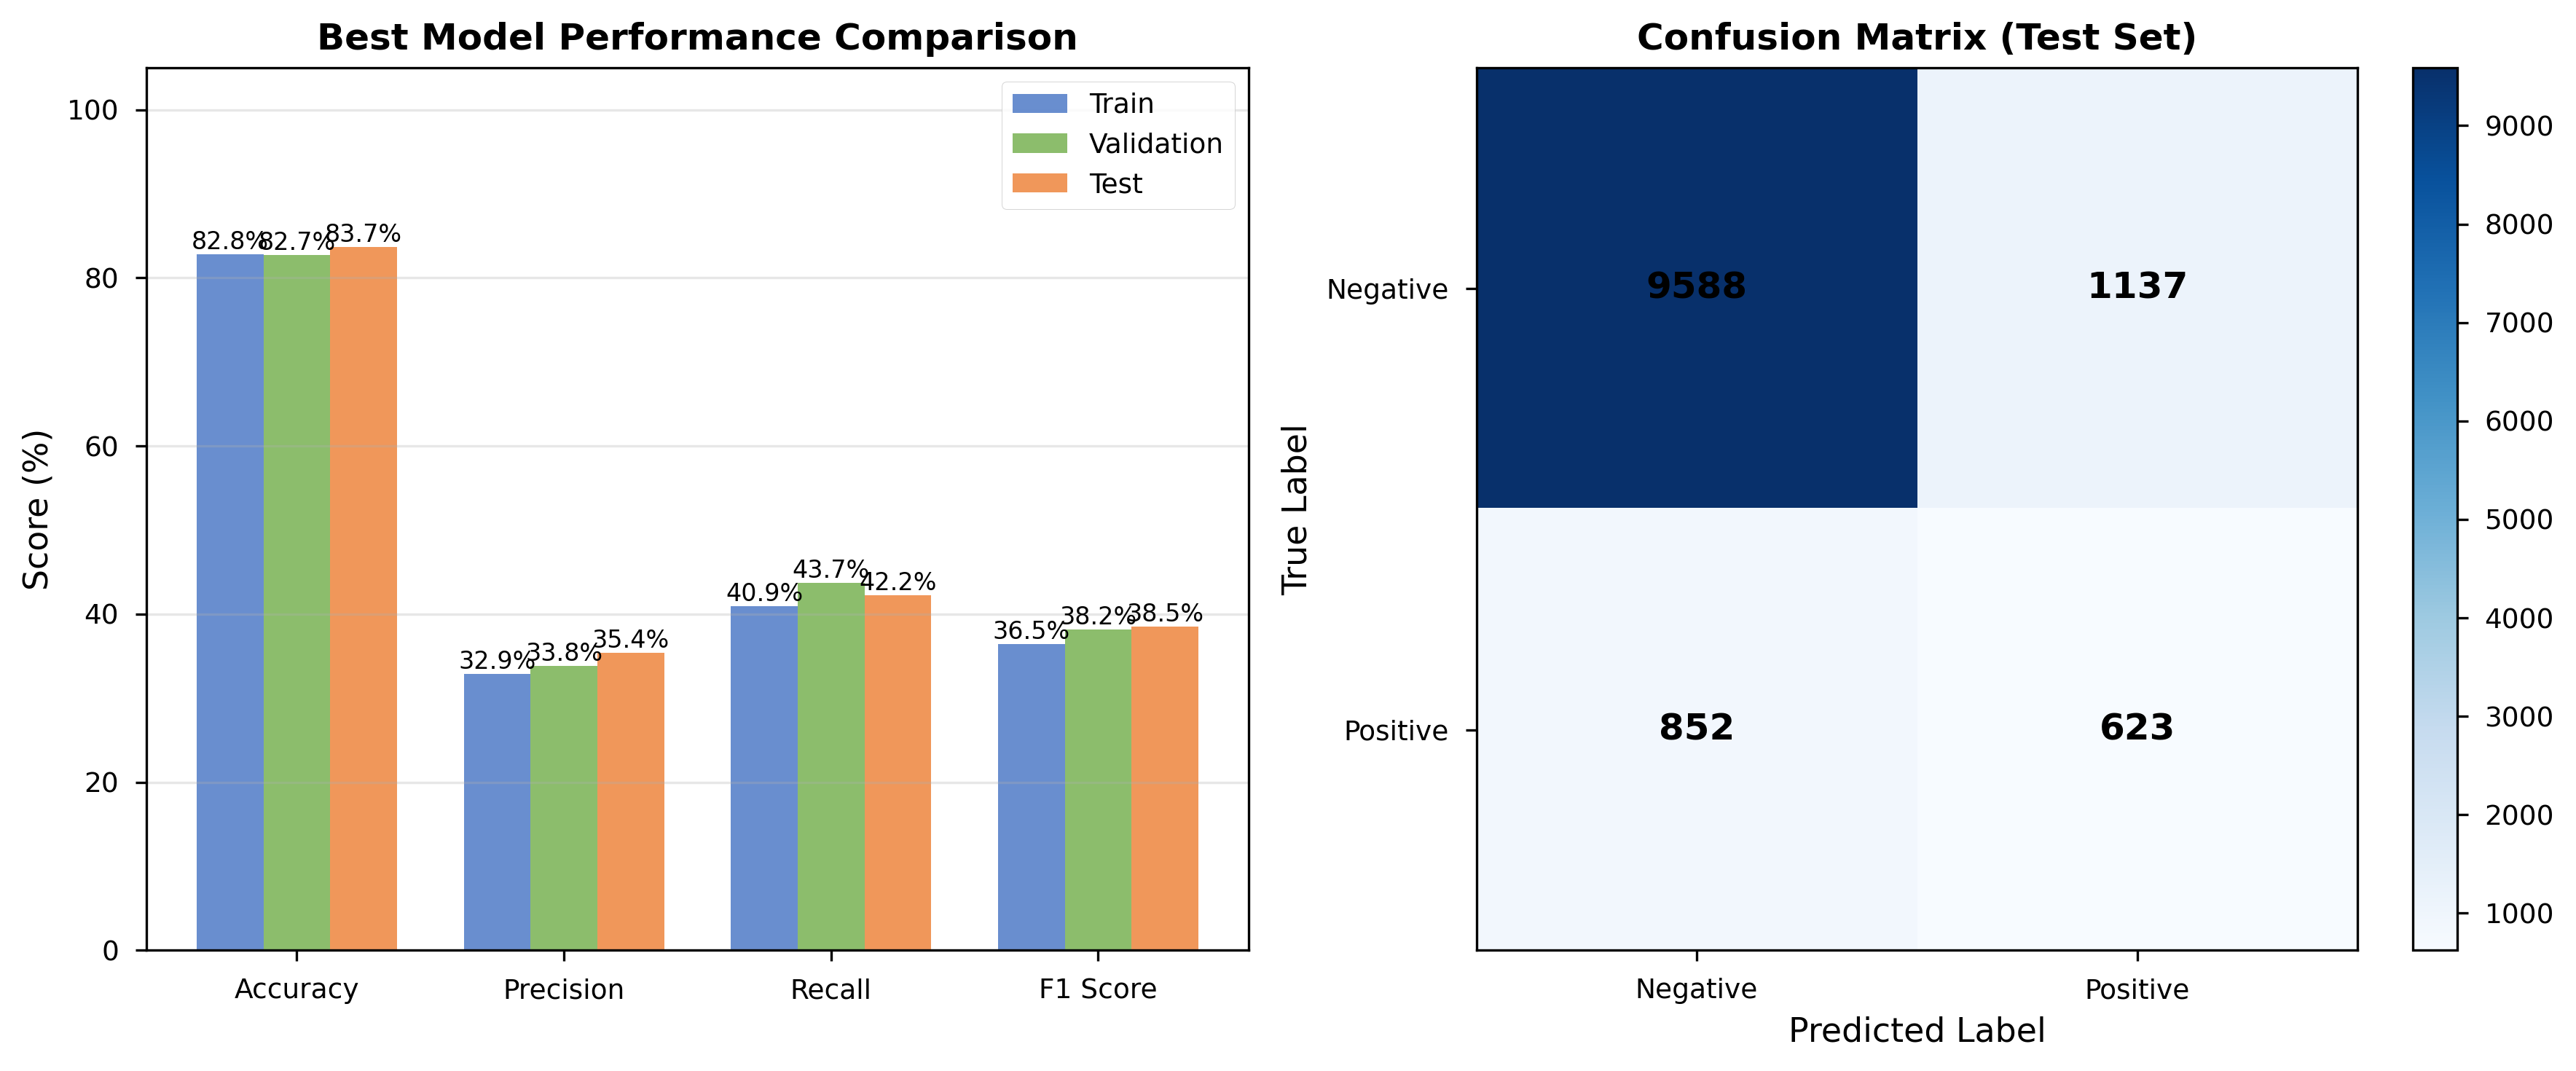

In [ ]:
# ============= Create a second figure: Final Performance Comparison =============
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot comparing final metrics
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
train_final = [metrics_90_day[0]['accuracy']*100, metrics_90_day[0]['precision']*100, 
               metrics_90_day[0]['recall']*100, metrics_90_day[0]['f1']*100]
val_final = [metrics_90_day[1]['accuracy']*100, metrics_90_day[1]['precision']*100, 
             metrics_90_day[1]['recall']*100, metrics_90_day[1]['f1']*100]
test_final = [metrics_90_day[2]['accuracy']*100, metrics_90_day[2]['precision']*100, 
              metrics_90_day[2]['recall']*100, metrics_90_day[2]['f1']*100]

x = np.arange(len(metrics_names))
width = 0.25

bars1 = ax1.bar(x - width, train_final, width, label='Train', color='#4472C4', alpha=0.8)
bars2 = ax1.bar(x, val_final, width, label='Validation', color='#70AD47', alpha=0.8)
bars3 = ax1.bar(x + width, test_final, width, label='Test', color='#ED7D31', alpha=0.8)

ax1.set_ylabel('Score (%)')
ax1.set_title('Best Model Performance Comparison', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0, 105])

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

# Confusion matrix visualization for test set
confusion_data = [
    [metrics_90_day[2]['true_neg'], metrics_90_day[2]['false_pos']],
    [metrics_90_day[2]['false_neg'], metrics_90_day[2]['true_pos']]
]

im = ax2.imshow(confusion_data, cmap='Blues', aspect='auto')
ax2.set_xticks([0, 1])
ax2.set_yticks([0, 1])
ax2.set_xticklabels(['Negative', 'Positive'])
ax2.set_yticklabels(['Negative', 'Positive'])
ax2.set_xlabel('Predicted Label')
ax2.set_ylabel('True Label')
ax2.set_title('Confusion Matrix (Test Set)', fontweight='bold')

# Add text annotations
for i in range(2):
    for j in range(2):
        text = ax2.text(j, i, confusion_data[i][j],
                       ha="center", va="center", color="black", fontsize=12, fontweight='bold')

plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.savefig('final_performance_comparison.pdf', bbox_inches='tight', dpi=300)
print("Saved: final_performance_comparison.pdf")
plt.show()

## Train Model on Synthetic Data, Regression Task
This section loads the synthetic data as a regression task, to predict the remaining recurrence time until event at each timestep. Note, we set our options to use spatial attention, and we left out the global loading rate node. In theory, using spatial edges vs spatial attention should not be relevant because there are no spatial correlations in the synthetic data.

In [111]:
REGRESSION_USE_SPATIAL_EDGES = False
REGRESSION_USE_SPATIAL_ATTENTION = True
REGRESSION_USE_LOADING_RATES = False

In [112]:
print("Building spatial graphs, regression task")
all_samples_regression, dist_matrix = build_temporal_snapshot_graph(df, use_regression_task=True, use_spatial_edges=REGRESSION_USE_SPATIAL_EDGES, use_spatial_attention=REGRESSION_USE_SPATIAL_ATTENTION, use_loading_rates=REGRESSION_USE_LOADING_RATES, CONTEXT_LENGTH=int(LOOKBACK_DAYS / 30))

TRAIN_INDEX_END = int(len(all_samples_regression) * TRAIN_SPLIT)
VAL_INDEX_END = TRAIN_INDEX_END + int(len(all_samples_regression) * VAL_SPLIT)

train_samples_regression = all_samples_regression[:TRAIN_INDEX_END]
val_samples_regression = all_samples_regression[TRAIN_INDEX_END:VAL_INDEX_END]
test_samples_regression = all_samples_regression[VAL_INDEX_END:]

train_loader_regression = DataLoader(train_samples_regression, batch_size=BATCH_SIZE, shuffle=True)
val_loader_regression = DataLoader(val_samples_regression, batch_size=BATCH_SIZE, shuffle=True)
test_loader_regression = DataLoader(test_samples_regression, batch_size=BATCH_SIZE, shuffle=True)

Building spatial graphs, regression task


/Users/brandonliu/Documents/Stanford/CS 224W/CS224W_Project/src/data_utils.py:292: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  subgraph_hetero_sample['earthquake_source'].y = torch.tensor(hetero_data['earthquake_source'].y[node_idx][predict_nodes_mask])


In [113]:
print("Training model")
model_regression, history = train_rGCN_temporal_snapshot(train_loader_regression, val_loader_regression, test_loader_regression, use_regression_task=True, use_spatial_attention=False, use_spatial_edges=True, use_loading_rates=False, dist_matrix=dist_matrix)

print("Training complete")
torch.save({
    'model_state': model_regression.state_dict(),
}, os.path.join(OUT_DIR, "rgcn_unified_regression.pth"))

Training model
Epoch 005 | Loss 277.1497 | Val Loss 247.1212
Epoch 010 | Loss 214.5922 | Val Loss 185.1113
Epoch 015 | Loss 202.6119 | Val Loss 183.3604
Epoch 020 | Loss 201.0986 | Val Loss 182.9391
Epoch 025 | Loss 185.7015 | Val Loss 181.3515
Epoch 030 | Loss 177.9247 | Val Loss 179.2273
Epoch 035 | Loss 177.5291 | Val Loss 180.4831
Epoch 040 | Loss 176.3834 | Val Loss 179.8879
Epoch 045 | Loss 175.4408 | Val Loss 180.4385
Epoch 050 | Loss 175.8270 | Val Loss 181.5231
Epoch 055 | Loss 174.9219 | Val Loss 180.7131
Epoch 060 | Loss 175.3609 | Val Loss 181.0950
Epoch 065 | Loss 174.3536 | Val Loss 182.3201
Epoch 070 | Loss 174.0347 | Val Loss 178.9262
Epoch 075 | Loss 173.2457 | Val Loss 184.7589
Epoch 080 | Loss 172.8057 | Val Loss 185.3261
Epoch 085 | Loss 172.0136 | Val Loss 183.3376
Epoch 090 | Loss 171.9589 | Val Loss 183.3826
Epoch 095 | Loss 171.3205 | Val Loss 184.3790
Epoch 100 | Loss 170.8481 | Val Loss 181.1575
Epoch 105 | Loss 170.6105 | Val Loss 183.3755
Epoch 110 | Loss 17

In [114]:
pred_df_regression = evaluate_model(model_regression, (train_samples_regression, val_samples_regression, test_samples_regression), True)
# Save predictions summary with model-specific naming
out_preds_dir = os.path.join(OUT_DIR, 'predictions')
os.makedirs(out_preds_dir, exist_ok=True)
preds_filename = os.path.join(out_preds_dir, f'predictions_summary_rgcn_regression.csv')
pred_df_regression.to_csv(preds_filename, index=False)
print(f"Saved predictions summary to: {preds_filename}")

/var/folders/31/mjzvzqx14b70qrgwz5w_xx100000gn/T/ipykernel_78100/3883752871.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_out.append(torch.tensor(out))


Saved predictions summary to: ../model/predictions/predictions_summary_rgcn_regression.csv


## Regression Task Distribution Analysis
Here, we show the true and predicted distributions for the regression task. In the synthetic data, our data is generated from a well defined inverse gaussian distribution, so the comparison is also well defined. In this notebook, we select two nodes at two ends of mean recurrence time. See the Medium blogpost for analysis.

In [ ]:
# Creates a dictionary, where each key represents a node, and the corresponding values represent the labels at each timestamp.

prediction_series = {}
label_series = {}

for row in pred_df_regression.iterrows():
    row = row[1]
    preds_for_node = prediction_series.setdefault(row["node_idx"], [])
    labels_for_node = label_series.setdefault(row["node_idx"], [])
    preds_for_node.append(row["predicted_label"])
    labels_for_node.append(row["true_label"])

In [ ]:
def get_recurrence_times_recurrence_prediction(series, tolerance=0):
    """Finds the recurrence time predictions immediately following an event (thus ignores all the predictions conditioned on time already passed)"""
    recurrence_times = []
    index_of_recurrence = []
    last_pred = float("-inf")
    for i, pred in enumerate(series):
        if pred > last_pred + tolerance:
            index_of_recurrence.append(i)
            recurrence_times.append(pred)
        last_pred = pred
    return recurrence_times, index_of_recurrence

In [ ]:
def plot_recurrence_distributions(label_series, prediction_series, node_id):
    """Creates two histograms: one of the real labels, and one of the predictions"""
    recurrence_times, index_of_recurrence = get_recurrence_times_recurrence_prediction(label_series[node_id])
    recurrence_times = np.asarray(recurrence_times)
    predicted_rec_times = np.asarray(prediction_series[node_id])[np.array(index_of_recurrence) + 1]
    fig1, (ax1, ax2) = plt.subplots(nrows=1, ncols=2)
    fig1.set_size_inches(10, 5)

    ax1.hist(recurrence_times)
    ax1.axvline(recurrence_times.mean(), color='k', linestyle='dashed')
    ax1_ylim = ax1.get_ylim()[1] * .9
    ax1.text(recurrence_times.mean()*1.1, ax1_ylim, 'Mean: {:.2f}'.format(recurrence_times.mean()))
    ax1.set_xlabel("Recurrence time")
    ax1.set_ylabel("Count")
    ax1.set_title("True recurrence time distribution for node {}".format(node_id))

    ax2.hist(predicted_rec_times)
    ax2.axvline(predicted_rec_times.mean(), color='k', linestyle='dashed')
    ax2_ylim = ax2.get_ylim()[1] * .9
    ax2.text(predicted_rec_times.mean()*1.1, ax2_ylim, 'Mean: {:.2f}'.format(predicted_rec_times.mean()))
    ax2.set_xlabel("Predicted recurrence time")
    ax2.set_ylabel("Count")
    ax2.set_title("Predicted recurrence time distribution for node {}".format(node_id))

    return fig1

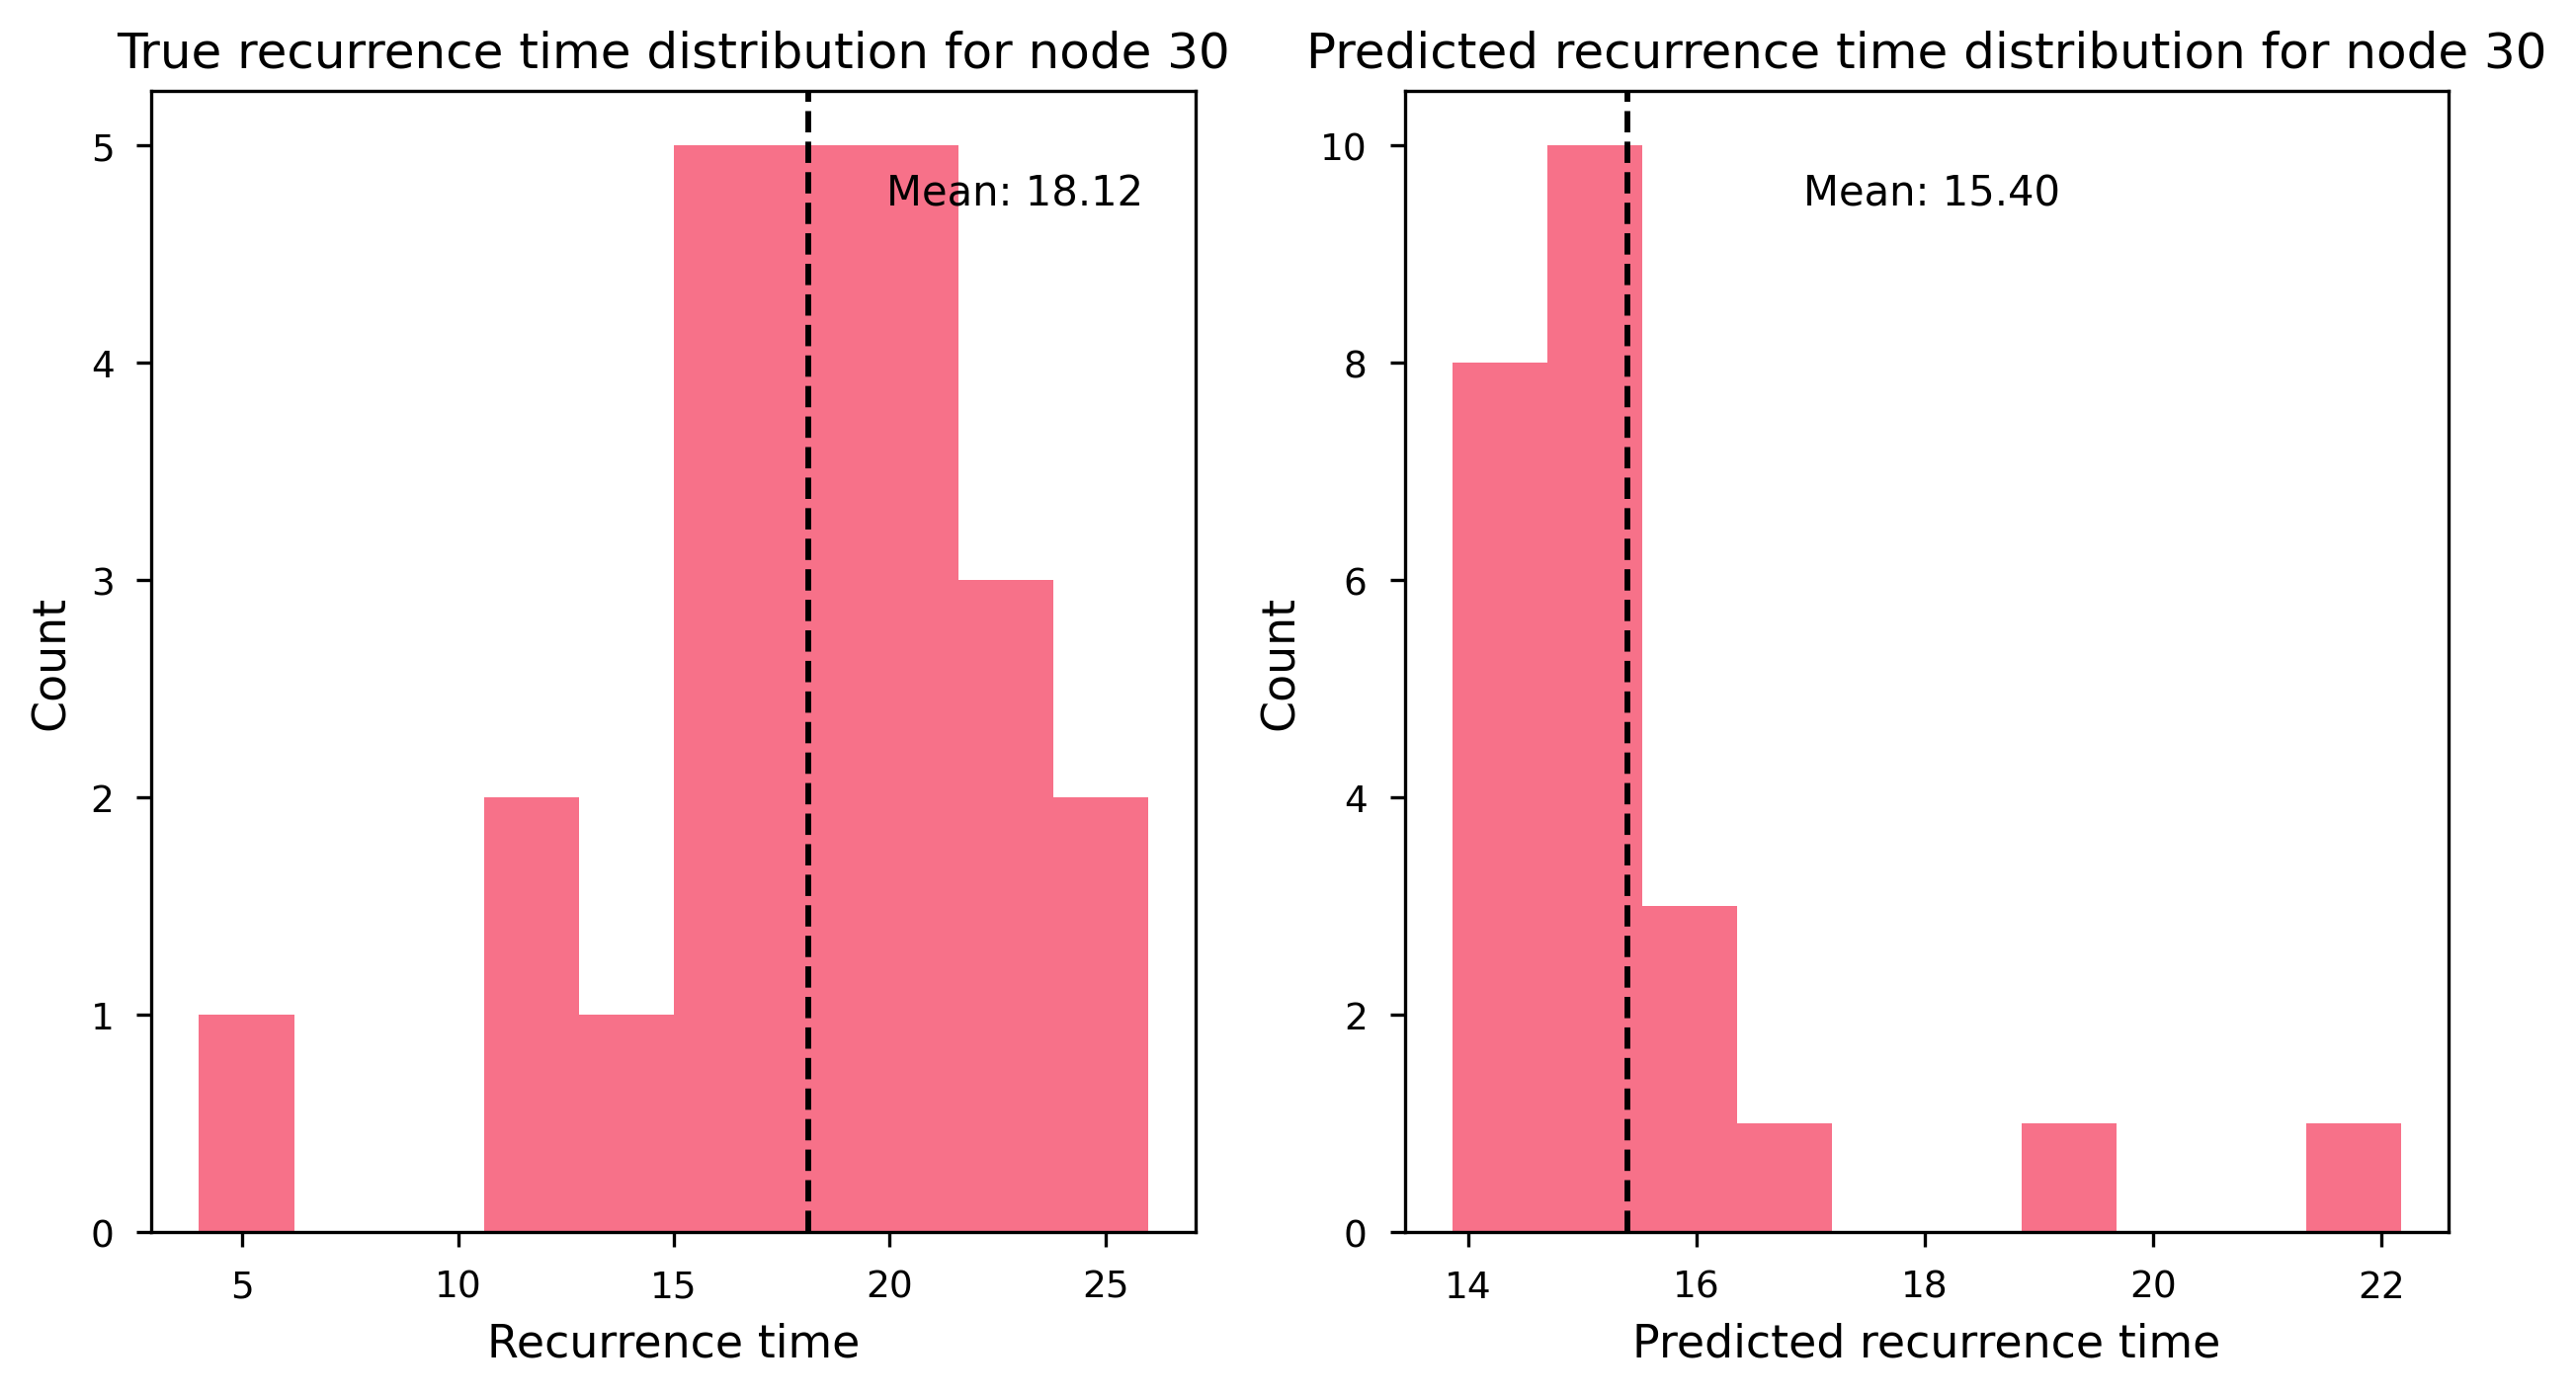

In [120]:
fig_node_1 = plot_recurrence_distributions(label_series, prediction_series, 30)

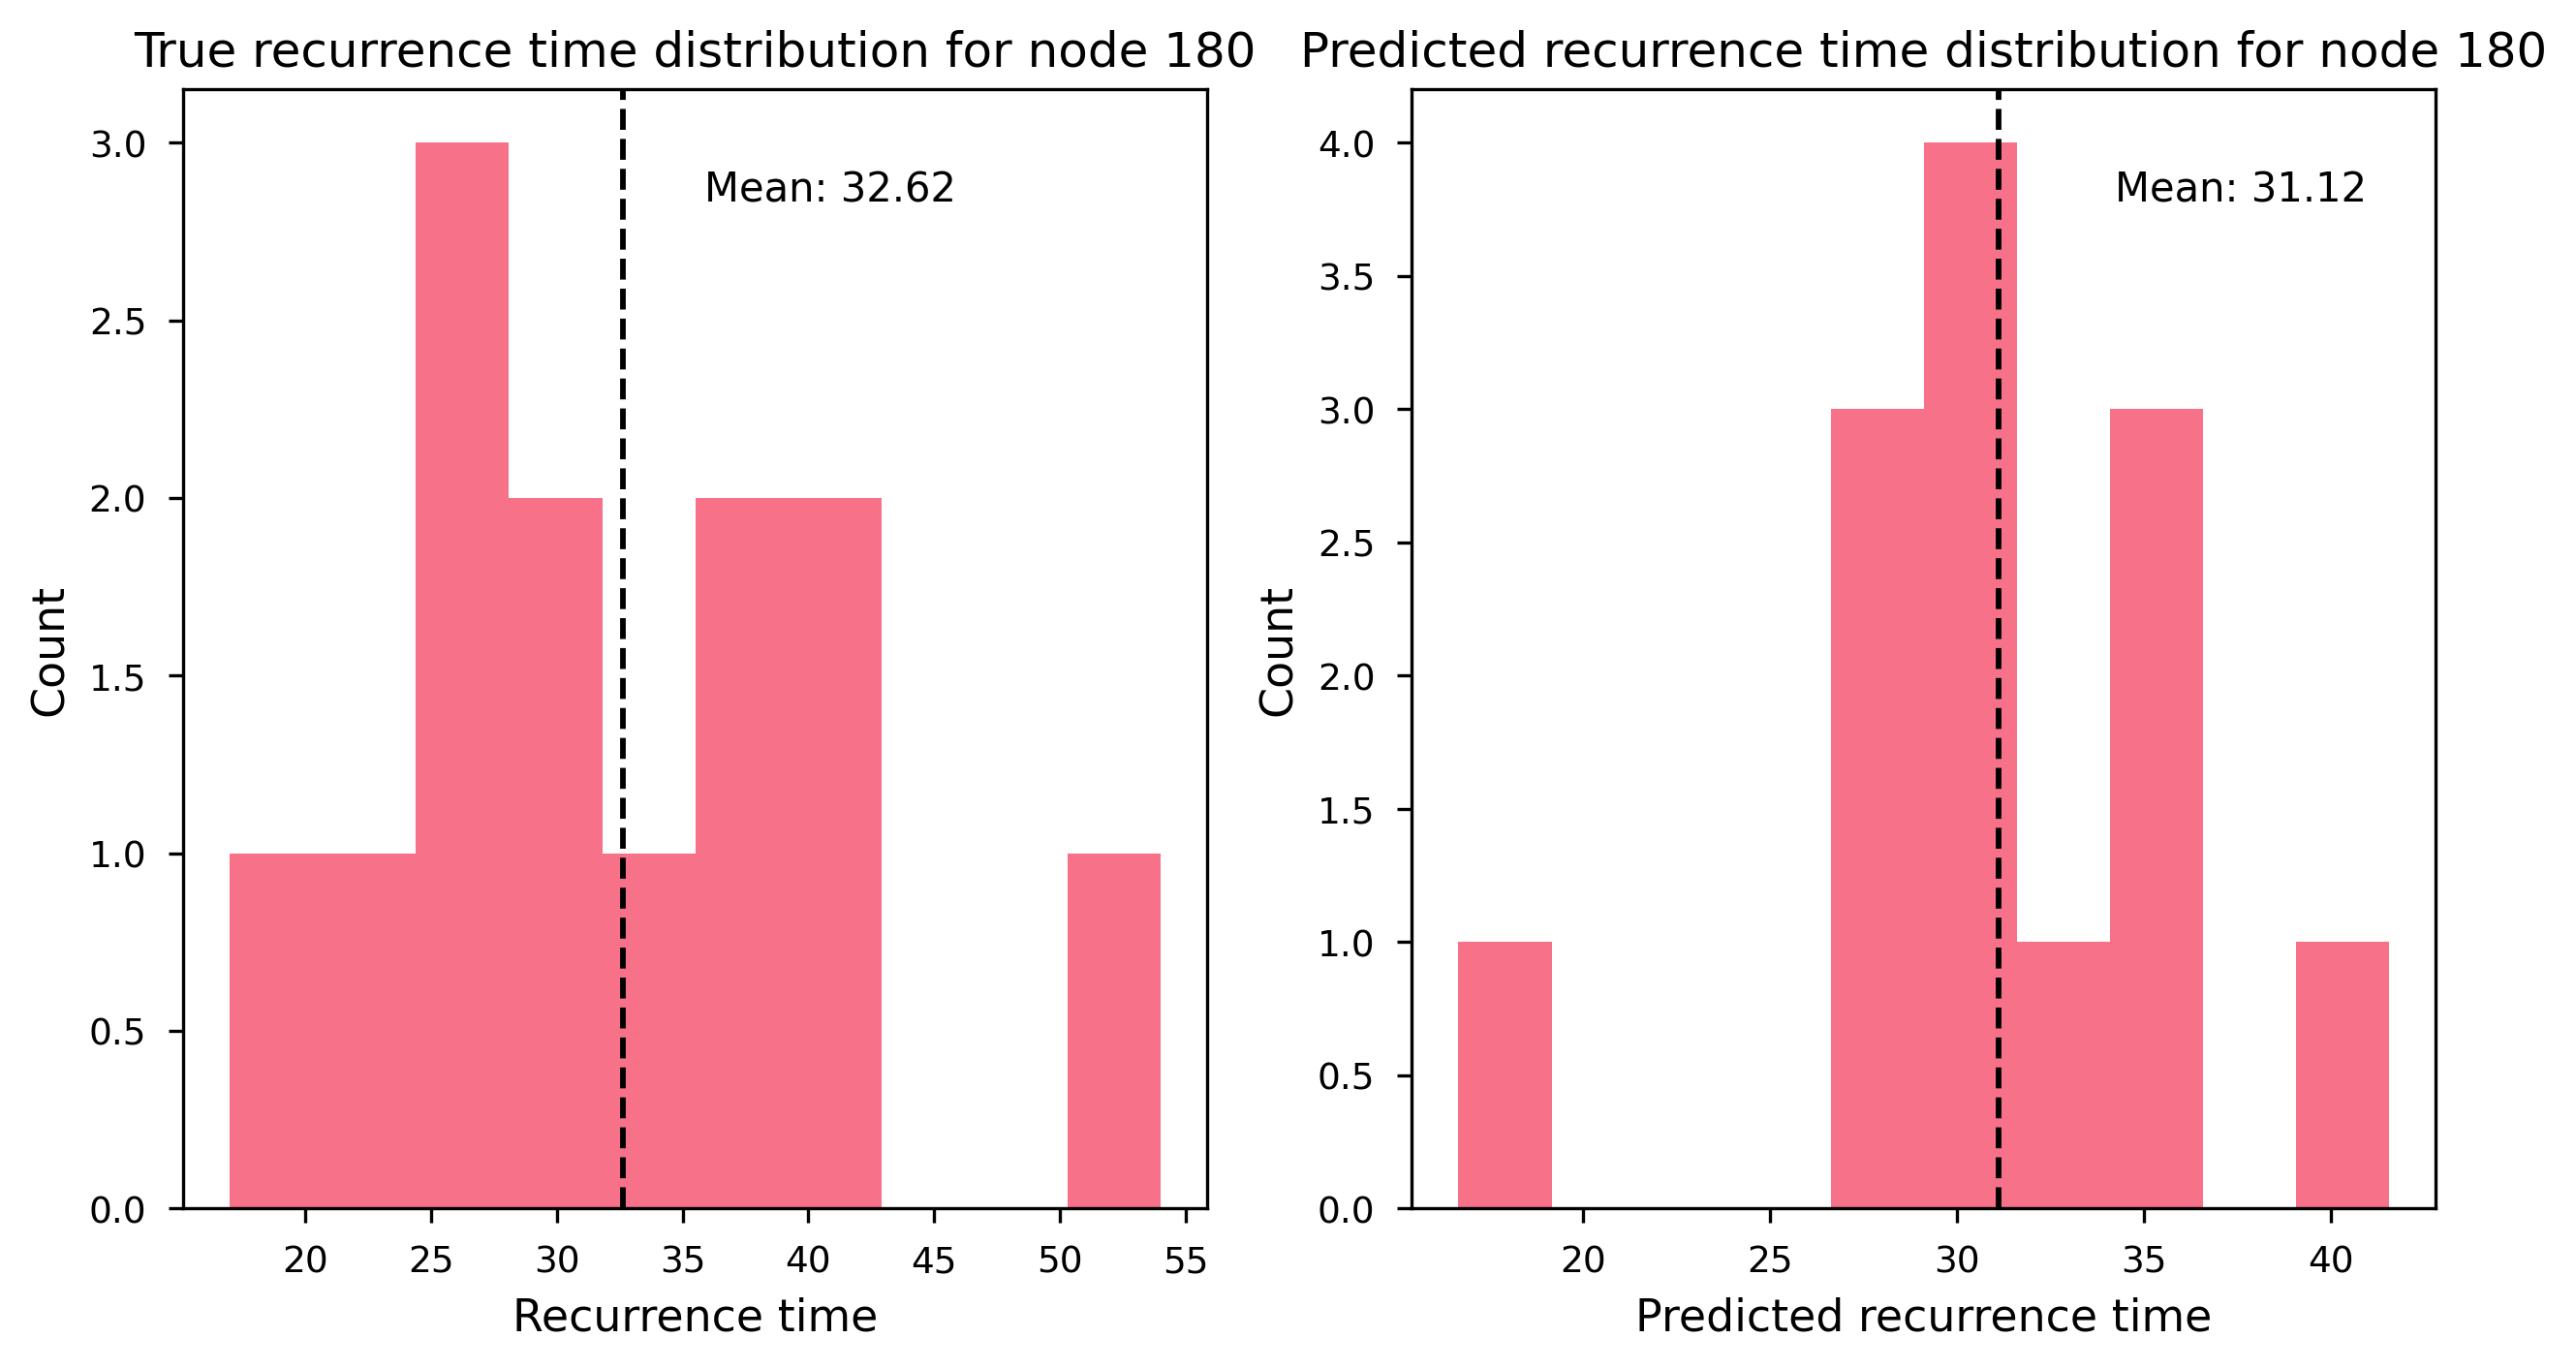

In [121]:
fig_node_2 = plot_recurrence_distributions(label_series, prediction_series, 180)